In [53]:
from Other_classes import (FoodDataset, PatchEmbedding, Encoder_block, 
TransformerEncoder, insert_mask_tokens, MAE_Decoder_Block, MAEDecoder, patchify, MultiParquetFoodDataset)

In [54]:
from positional_encoding import Positional_Encoding

In [55]:
from torchvision import transforms
import torch
from torch import nn
from PIL import Image

Image → patchify → mask → encoder → decoder → reconstructed image

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [58]:
def random_masking(x, mask_ratio=0.75):
    
    """
    x: [B, N, D]
    """
    
    B, N, D = x.shape
    
    len_keep = int(N * (1 - mask_ratio))
    
    # ---- random noise generate ----
    noise = torch.rand(B, N, device=x.device)
    
    # ---- shuffle indices ----
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    
    # ---- keep first tokens ----
    ids_keep = ids_shuffle[:, :len_keep]
    
    x_masked = torch.gather(
        x,
        dim=1,
        index=ids_keep.unsqueeze(-1).repeat(1, 1, D)
    )
    
    # ---- create mask ----
    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    
    # unshuffle mask
    mask = torch.gather(mask, dim=1, index=ids_restore)
    
    return x_masked, mask, ids_restore

In [59]:

class MAE_inference(nn.Module):

    def __init__(self, patch_embed, encoder, decoder,seq_len=196, embed_dim=768):
        super().__init__()

        self.patch_embed = patch_embed
        self.encoder = encoder
        self.decoder = decoder
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_encoding = Positional_Encoding(seq_len, embed_dim)

    def forward(self, images):

        tokens = self.patch_embed(images)

        visible_tokens, mask, ids_restore = random_masking(tokens)

        visible_tokens = self.pos_encoding(visible_tokens)

        latent = self.encoder(visible_tokens)

        decoder_input = insert_mask_tokens(
            latent, ids_restore, self.mask_token
        )

        pred = self.decoder(decoder_input)

        target = patchify(images)

        
        target = (target - target.mean(dim=-1, keepdim=True)) / \
                (target.std(dim=-1, keepdim=True) + 1e-6)

        return pred, target, mask

In [60]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [61]:
img = Image.open("test_image.jpg").convert("RGB")
img_tensor = transform(img).unsqueeze(0).to(device)  # [1,3,224,224]

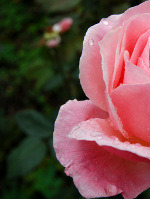

In [62]:
img

In [63]:
img_tensor.shape

torch.Size([1, 3, 224, 224])

In [64]:
img_tensor.device

device(type='cuda', index=0)

In [65]:
patch_embed = PatchEmbedding().to(device)
# batch = next(iter(dataloader))
# print("batch_shape: ", batch.shape)

tokens = patch_embed(img_tensor)
print("tokens_shape:" , tokens.shape)


visible_tokens, mask, ids_restore = random_masking(tokens)


d_model = 768  # main model dimension
num_heads = 8  # number of heads
d_ff = 2048    # feedforward hidden dimension
seq_len = 196  # max input length
vocab_size = 30000

pos_encoding = Positional_Encoding(seq_len, d_model).to(device)
visible_tokens = pos_encoding(visible_tokens)

encoder = TransformerEncoder(num_layers=8, d_model=768, d_ff=2048, num_heads=8).to(device)

latent = encoder(visible_tokens)
print("latent.shape: ", latent.shape)

mask_token = nn.Parameter(torch.zeros(1, 1, 768)).to(device)

decoder = insert_mask_tokens(latent, ids_restore, mask_token)
print("decoder_input_shape: ", decoder_input.shape)

tokens_shape: torch.Size([1, 196, 768])
latent.shape:  torch.Size([1, 49, 768])
decoder_input_shape:  torch.Size([1, 196, 768])


In [66]:
# decoder = MAEDecoder()

In [67]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MAE_inference(patch_embed, encoder, decoder).to(device)
model.load_state_dict(torch.load("models/mae_model.pth", map_location=device))
model.eval()

RuntimeError: Error(s) in loading state_dict for MAE_inference:
	Unexpected key(s) in state_dict: "decoder.pos_embed.pe", "decoder.blocks.0.attn.Q.weight", "decoder.blocks.0.attn.Q.bias", "decoder.blocks.0.attn.K.weight", "decoder.blocks.0.attn.K.bias", "decoder.blocks.0.attn.V.weight", "decoder.blocks.0.attn.V.bias", "decoder.blocks.0.attn.fc_out.weight", "decoder.blocks.0.attn.fc_out.bias", "decoder.blocks.0.ffn.fc1.weight", "decoder.blocks.0.ffn.fc1.bias", "decoder.blocks.0.ffn.fc2.weight", "decoder.blocks.0.ffn.fc2.bias", "decoder.blocks.0.norm1.weight", "decoder.blocks.0.norm1.bias", "decoder.blocks.0.norm2.weight", "decoder.blocks.0.norm2.bias", "decoder.blocks.1.attn.Q.weight", "decoder.blocks.1.attn.Q.bias", "decoder.blocks.1.attn.K.weight", "decoder.blocks.1.attn.K.bias", "decoder.blocks.1.attn.V.weight", "decoder.blocks.1.attn.V.bias", "decoder.blocks.1.attn.fc_out.weight", "decoder.blocks.1.attn.fc_out.bias", "decoder.blocks.1.ffn.fc1.weight", "decoder.blocks.1.ffn.fc1.bias"

In [68]:
with torch.no_grad():
    pred, target, mask = model(img_tensor)

TypeError: 'Tensor' object is not callable

In [69]:
pred.shape, target.shape, mask.shape 

(torch.Size([1, 196, 768]), torch.Size([1, 196, 768]), torch.Size([1, 196]))

In [70]:
loss = (pred - target) ** 2
loss = loss.mean(dim=-1)          # (1, 196)
masked_loss = (loss * mask).sum() / mask.sum()

print("Masked reconstruction loss:", masked_loss.item())

Masked reconstruction loss: 1.310103178024292


In [71]:
def unpatchify(patches, patch_size=16, img_size=224):
    """
    patches: [B, N, C*ps*ps]
    return:  [B, C, H, W]
    """
    B, N, D = patches.shape
    C = 3
    h = w = img_size // patch_size  # 14

    patches = patches.view(B, N, C, patch_size, patch_size)
    # [B, N, C, ps, ps]

    patches = patches.view(B, h, w, C, patch_size, patch_size)
    # [B, 14, 14, C, ps, ps]

    patches = patches.permute(0, 3, 1, 4, 2, 5)
    # [B, C, 14, ps, 14, ps]

    images = patches.reshape(B, C, img_size, img_size)
    return images

In [72]:
recon_img = unpatchify(pred)
orig_img  = img_tensor

In [73]:
mask_img = mask.reshape(1, 14, 14)
mask_img = mask_img.repeat_interleave(16, 1).repeat_interleave(16, 2)
mask_img = mask_img.unsqueeze(1)   # (1,1,224,224)

In [74]:
final_img = orig_img * (1 - mask_img) + recon_img * mask_img

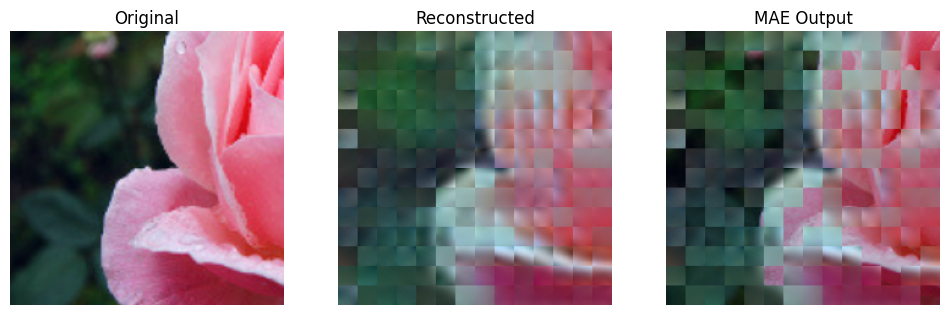

In [75]:
import matplotlib.pyplot  as plt
def show(img, title):
    img = img[0].cpu().permute(1,2,0)
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); show(orig_img, "Original")
plt.subplot(1,3,2); show(recon_img, "Reconstructed")
plt.subplot(1,3,3); show(final_img, "MAE Output")
plt.show()

In [27]:
rest_img = Image.open("rest_image.jpg").convert("RGB")
# rest_tensor = transform(img).unsqueeze(0).to(device)  # [1,3,224,224]

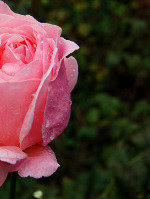

In [28]:
rest_img

In [29]:
with torch.no_grad():
    p = patchify(img_tensor)
    x_rec = unpatchify(p)

print((img_tensor - x_rec).abs().mean())

tensor(0., device='cuda:0')


In [30]:
################################### 

In [45]:
class MAE_inference(nn.Module):

    def __init__(self, seq_len=196, embed_dim=768):
        super().__init__()

        self.patch_embed = PatchEmbedding()
        self.encoder = TransformerEncoder(
            num_layers=8,
            d_model=768,
            d_ff=2048,
            num_heads=8
        )

        self.decoder = MAEDecoder(   # ✅ MODULE
            depth=4,
            embed_dim=768,
            d_ff=2048,
            num_heads=8,
            patch_dim=768
        )

        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_encoding = Positional_Encoding(seq_len, embed_dim)

    def forward(self, images):

        tokens = self.patch_embed(images)
        visible_tokens, mask, ids_restore = random_masking(tokens)

        visible_tokens = self.pos_encoding(visible_tokens)
        latent = self.encoder(visible_tokens)

        decoder_input = insert_mask_tokens(
            latent, ids_restore, self.mask_token
        )

        pred = self.decoder(decoder_input)
        target = patchify(images)

        target = (target - target.mean(dim=-1, keepdim=True)) / \
                 (target.std(dim=-1, keepdim=True) + 1e-6)

        return pred, target, mask

In [47]:
device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint = torch.load("checkpoints/mae_epoch_new_4.pth", map_location=device)

model.load_state_dict(checkpoint["model"])  # 🔥 MAIN FIX
model.eval()

MAE_inference(
  (patch_embed): PatchEmbedding(
    (proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x Encoder_block(
        (ffn): feedforward(
          (fc1): Linear(in_features=768, out_features=2048, bias=True)
          (relu): ReLU()
          (fc2): Linear(in_features=2048, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (multi_att): MultiHeadAttention(
          (Q): Linear(in_features=768, out_features=768, bias=True)
          (K): Linear(in_features=768, out_features=768, bias=True)
          (V): Linear(in_features=768, out_features=768, bias=True)
          (fc_out): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm_layer1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm_layer2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
     

In [48]:
with torch.no_grad():
    pred, target, mask = model(img_tensor)

In [49]:
recon_img = unpatchify(pred)
orig_img  = img_tensor

In [50]:
mask_img = mask.reshape(1, 14, 14)
mask_img = mask_img.repeat_interleave(16, 1).repeat_interleave(16, 2)
mask_img = mask_img.unsqueeze(1)   # (1,1,224,224)

In [51]:
final_img = orig_img * (1 - mask_img) + recon_img * mask_img

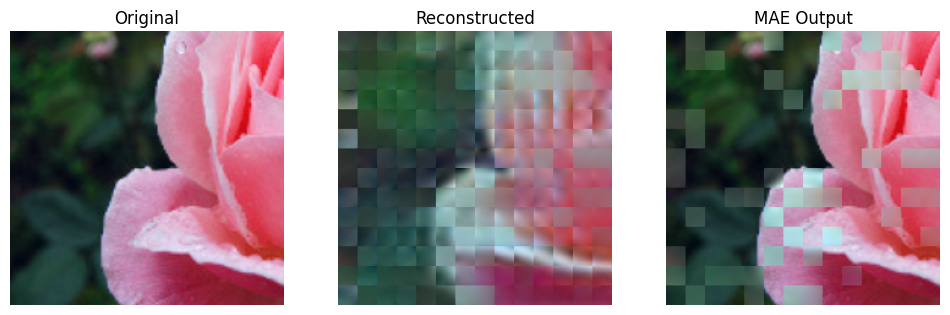

In [52]:
import matplotlib.pyplot  as plt
def show(img, title):
    img = img[0].cpu().permute(1,2,0)
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); show(orig_img, "Original")
plt.subplot(1,3,2); show(recon_img, "Reconstructed")
plt.subplot(1,3,3); show(final_img, "MAE Output")
plt.show()